# Predicting ICU Admission from COVID-19 Open Data with PySpark MLlib

Machine-learning pipeline built with PySpark on the open COVID-19 patient dataset published by Mexico's Ministry of Health (Secretaría de Salud). Goal: predict ICU admission from clinical and demographic variables.

*Original code comments and analysis notes are in Spanish.*

In [1]:
import findspark
findspark.init()
import pyspark
import random
import os.path
from pyspark.sql.functions import *

from pyspark import SparkConf, SparkContext, SQLContext, HiveContext
conf = SparkConf()
conf.setMaster("local[1]")
conf.setAppName('covid_icu_prediction')
sc = SparkContext(conf=conf)


## Data loading and variable selection

Load the CSV, keep laboratory-confirmed positive cases (`RESULTADO_LAB == 1`), and select the clinical and demographic variables used in the analysis.

In [2]:
sqlContext = SQLContext(sc)

df = sqlContext.read.csv(
    path="file:///22.519/data/base_de_datos_covid.csv",
    header="true",
    inferSchema="true",
    quote='"',
    sep= ","
)

In [3]:
# Filtrado de datos para casos positivos de COVID-19
df = df.filter(df.RESULTADO_LAB == 1)

In [4]:
# Contamos el número de observaciones después del filtrado
num_pacientes_positivos = df.count()

print("Número de pacientes que han dado positivo para COVID-19:", num_pacientes_positivos)

Número de pacientes que han dado positivo para COVID-19: 457912


In [5]:
df = df.select("SEXO", "EDAD", "FECHA_DEF", "DIABETES", "EPOC", "ASMA", 
                        "INMUSUPR", "HIPERTENSION", "OTRA_COM", "CARDIOVASCULAR", 
                        "OBESIDAD", "RENAL_CRONICA", "UCI")

In [6]:
df.show()

+----+----+----------+--------+----+----+--------+------------+--------+--------------+--------+-------------+---+
|SEXO|EDAD| FECHA_DEF|DIABETES|EPOC|ASMA|INMUSUPR|HIPERTENSION|OTRA_COM|CARDIOVASCULAR|OBESIDAD|RENAL_CRONICA|UCI|
+----+----+----------+--------+----+----+--------+------------+--------+--------------+--------+-------------+---+
|   2|  47|9999-99-99|       1|   2|   2|       2|           2|       2|             2|       2|            2| 97|
|   2|  54|9999-99-99|       2|   2|   2|       2|           2|       2|             2|       2|            2| 97|
|   1|  26|9999-99-99|       2|   2|   2|       2|           2|       2|             2|       2|            2| 97|
|   1|  32|9999-99-99|       1|   2|   2|       2|           1|       2|             2|       2|            2|  2|
|   1|  43|9999-99-99|       2|   2|   2|       2|           2|       2|             2|       2|            2| 97|
|   1|  49|9999-99-99|       2|   2|   2|       2|           2|       2|        

In [7]:
df.printSchema()

root
 |-- SEXO: integer (nullable = true)
 |-- EDAD: integer (nullable = true)
 |-- FECHA_DEF: string (nullable = true)
 |-- DIABETES: integer (nullable = true)
 |-- EPOC: integer (nullable = true)
 |-- ASMA: integer (nullable = true)
 |-- INMUSUPR: integer (nullable = true)
 |-- HIPERTENSION: integer (nullable = true)
 |-- OTRA_COM: integer (nullable = true)
 |-- CARDIOVASCULAR: integer (nullable = true)
 |-- OBESIDAD: integer (nullable = true)
 |-- RENAL_CRONICA: integer (nullable = true)
 |-- UCI: integer (nullable = true)



## Descriptive analysis and cleaning

Clinical variables are coded `1` = yes and `2` = no; `97`, `98` and `99` are missing-value codes (not applicable / unknown / unspecified). Rows carrying missing codes are dropped for every variable except `UCI` (ICU admission, the target), where any value other than 1 or 2 is recoded as 2 (not admitted).

In [8]:
# Análisis de valores nulos
for column in df.columns:
    print(column, " - Nulos: ", df.filter(col(column).isNull()).count())

# Eliminación de filas con valores nulos
df = df.dropna()

SEXO  - Nulos:  0
EDAD  - Nulos:  0
FECHA_DEF  - Nulos:  0
DIABETES  - Nulos:  0
EPOC  - Nulos:  0
ASMA  - Nulos:  0
INMUSUPR  - Nulos:  0
HIPERTENSION  - Nulos:  0
OTRA_COM  - Nulos:  0
CARDIOVASCULAR  - Nulos:  0
OBESIDAD  - Nulos:  0
RENAL_CRONICA  - Nulos:  0
UCI  - Nulos:  0


In [9]:
# Realizamos análisis descriptivo de las variables
df_descriptive_stats = df.describe()
df_descriptive_stats.show()
for column in df.columns:
    df.groupBy(column).agg(
        count(column).alias("count"), 
        (count(column) / df.count() * 100).alias("percentage")
    ).show()

+-------+------------------+------------------+----------+-----------------+------------------+-----------------+------------------+------------------+-----------------+------------------+------------------+-----------------+-----------------+
|summary|              SEXO|              EDAD| FECHA_DEF|         DIABETES|              EPOC|             ASMA|          INMUSUPR|      HIPERTENSION|         OTRA_COM|    CARDIOVASCULAR|          OBESIDAD|    RENAL_CRONICA|              UCI|
+-------+------------------+------------------+----------+-----------------+------------------+-----------------+------------------+------------------+-----------------+------------------+------------------+-----------------+-----------------+
|  count|            457912|            457912|    457912|           457912|            457912|           457912|            457912|            457912|           457912|            457912|            457912|           457912|           457912|
|   mean|1.5312614650849

In [9]:
# Filtramos filas donde todas las columnas clínicas tienen valores 1 o 2
df = df.filter(
    (df.SEXO.isin([1, 2])) &
    (df.DIABETES.isin([1, 2])) &
    (df.EPOC.isin([1, 2])) &
    (df.ASMA.isin([1, 2])) &
    (df.INMUSUPR.isin([1, 2])) &
    (df.HIPERTENSION.isin([1, 2])) &
    (df.OTRA_COM.isin([1, 2])) &
    (df.CARDIOVASCULAR.isin([1, 2])) &
    (df.OBESIDAD.isin([1, 2])) &
    (df.RENAL_CRONICA.isin([1, 2]))
)

In [11]:
df = df.withColumn("UCI", when(df.UCI.isin([1, 2]), df.UCI).otherwise(2))

In [12]:
num_registros = df.count()
print("Número de registros en el DataFrame:", num_registros)

Número de registros en el DataFrame: 454703


In [1]:
df_descriptive_stats = df.describe()
df_descriptive_stats.show()
for column in df.columns:
    df.groupBy(column).agg(
        count(column).alias("count"), 
        (count(column) / df.count() * 100).alias("percentage")
    ).show()

NameError: name 'df' is not defined

## Visual analysis

Convert the Spark DataFrame to pandas and plot: ICU admissions by age, deaths by age (a death is any record whose `FECHA_DEF` differs from `9999-99-99`), and the prevalence of each comorbidity over the full cohort.

In [13]:
from matplotlib import pyplot as plt

data = df.toPandas()

In [14]:
data.head()

,SEXO,EDAD,FECHA_DEF,DIABETES,EPOC,ASMA,INMUSUPR,HIPERTENSION,OTRA_COM,CARDIOVASCULAR,OBESIDAD,RENAL_CRONICA,UCI
0,2,47,9999-99-99,1,2,2,2,2,2,2,2,2,2
1,2,54,9999-99-99,2,2,2,2,2,2,2,2,2,2
2,1,26,9999-99-99,2,2,2,2,2,2,2,2,2,2
3,1,32,9999-99-99,1,2,2,2,1,2,2,2,2,2
4,1,43,9999-99-99,2,2,2,2,2,2,2,2,2,2


In [15]:
# Filtramos datos para pacientes ingresados en UCI
uci_ingresados = data[data['UCI'] == 1]

# Agrupamos por edad y contar
uci_por_edad = uci_ingresados.groupby('EDAD').size()

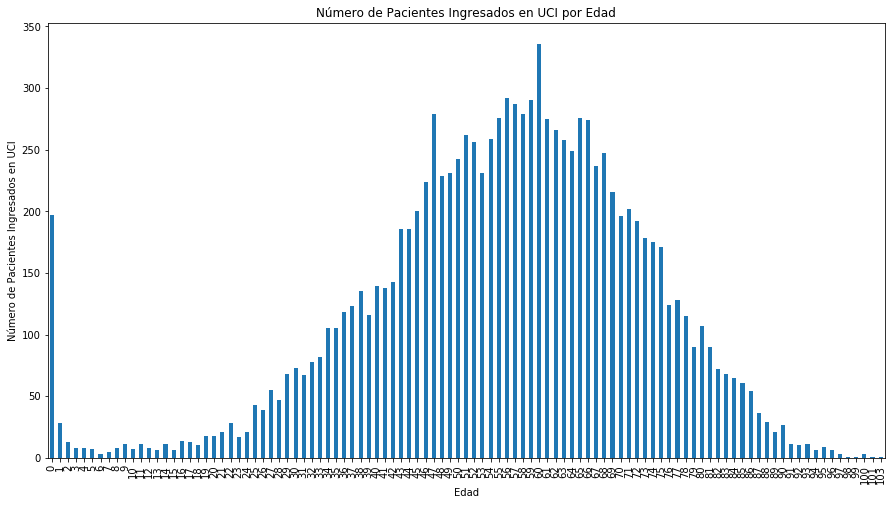

In [16]:
plt.figure(figsize=(15, 8))
uci_por_edad.plot(kind='bar')
plt.title('Número de Pacientes Ingresados en UCI por Edad')
plt.xlabel('Edad')
plt.ylabel('Número de Pacientes Ingresados en UCI')
plt.show()

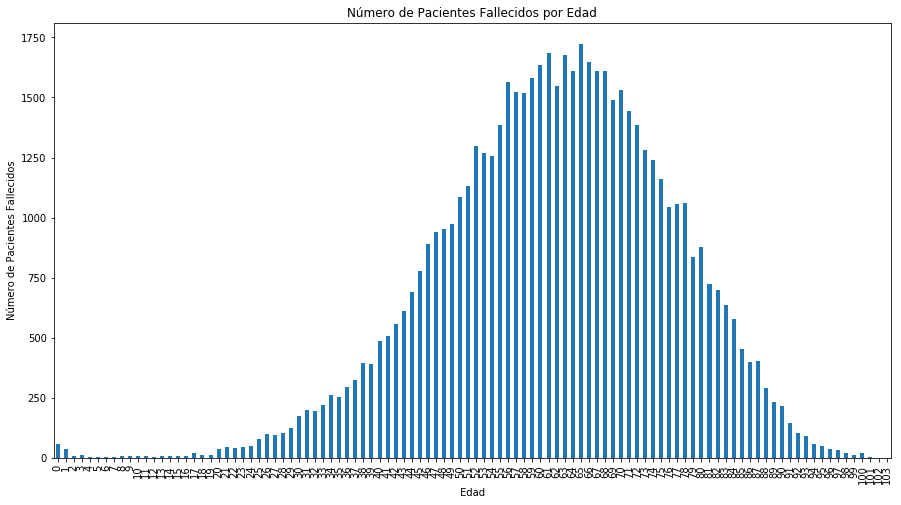

In [17]:
# Filtramos para incluir solo los pacientes fallecidos
pacientes_fallecidos = data[data['FECHA_DEF'] != '9999-99-99']

# Agrupamos por edad y contar
fallecidos_por_edad = pacientes_fallecidos.groupby('EDAD').size()

# Creamos un gráfico de barras
plt.figure(figsize=(15, 8))
fallecidos_por_edad.plot(kind='bar')
plt.title('Número de Pacientes Fallecidos por Edad')
plt.xlabel('Edad')
plt.ylabel('Número de Pacientes Fallecidos')
plt.show()

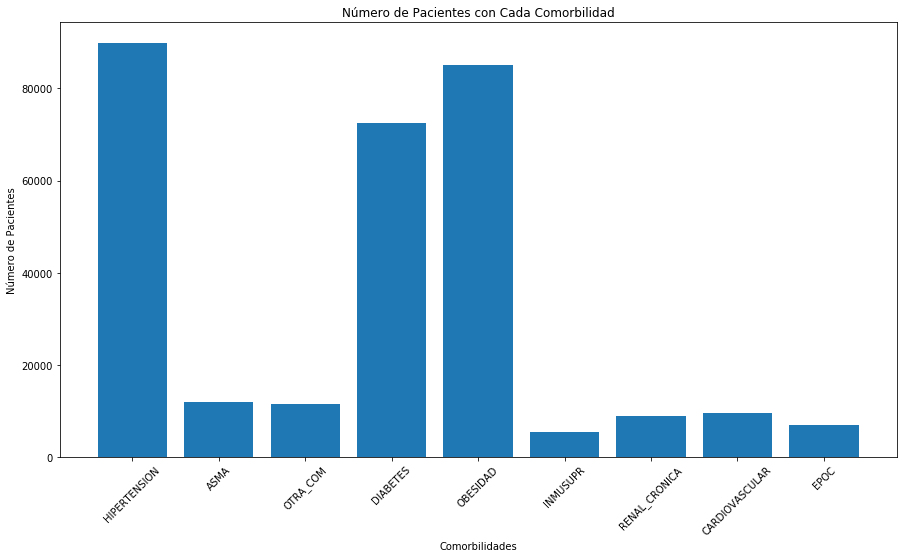

In [18]:
# Lista de comorbilidades
comorbilidades = ["DIABETES", "EPOC", "ASMA", "INMUSUPR", "HIPERTENSION", "OTRA_COM", "CARDIOVASCULAR", "OBESIDAD", "RENAL_CRONICA"]

# Contamos pacientes con cada comorbilidad
conteo_comorbilidades = {comorbilidad: data[data[comorbilidad] == 1].shape[0] for comorbilidad in comorbilidades}

# Creamos un gráfico de barras
plt.figure(figsize=(15, 8))
plt.bar(conteo_comorbilidades.keys(), conteo_comorbilidades.values())
plt.title('Número de Pacientes con Cada Comorbilidad')
plt.xlabel('Comorbilidades')
plt.ylabel('Número de Pacientes')
plt.xticks(rotation=45)
plt.show()

## Logistic regression

Assemble the feature vector with `VectorAssembler`, split 80/20 into train/test, and train a first logistic regression to predict `UCI`.

In [19]:
from pyspark.ml.feature import VectorAssembler

# Definimos las columnas de entrada para el modelo, es decir, las features
inputCol = ["SEXO", "EDAD", "DIABETES", "EPOC", "ASMA", "INMUSUPR", "HIPERTENSION", "OTRA_COM", "CARDIOVASCULAR", "OBESIDAD", "RENAL_CRONICA"]

# Inicializamos el VectorAssembler
assembler = VectorAssembler(inputCols=inputCol, outputCol="features")

# Transformamos los datos
df_transformed = assembler.transform(df)

# Mostramos el nuevo dataframe
df_transformed.show(truncate=False)

+----+----+----------+--------+----+----+--------+------------+--------+--------------+--------+-------------+---+----------------------------------------------+
|SEXO|EDAD|FECHA_DEF |DIABETES|EPOC|ASMA|INMUSUPR|HIPERTENSION|OTRA_COM|CARDIOVASCULAR|OBESIDAD|RENAL_CRONICA|UCI|features                                      |
+----+----+----------+--------+----+----+--------+------------+--------+--------------+--------+-------------+---+----------------------------------------------+
|2   |47  |9999-99-99|1       |2   |2   |2       |2           |2       |2             |2       |2            |2  |[2.0,47.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0]|
|2   |54  |9999-99-99|2       |2   |2   |2       |2           |2       |2             |2       |2            |2  |[2.0,54.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0]|
|1   |26  |9999-99-99|2       |2   |2   |2       |2           |2       |2             |2       |2            |2  |[1.0,26.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0]|
|1   |32  |9999-99-99|1     

In [20]:
# Define la proporción deseada para el conjunto de entrenamiento y prueba
train_ratio = 0.8  # Por ejemplo, 80% de entrenamiento y 20% de prueba

# Divide el DataFrame en conjuntos de entrenamiento y prueba
train_df, test_df = df_transformed.randomSplit([train_ratio, 1 - train_ratio], seed=42)

# Muestra la cantidad de registros en cada conjunto
print("Número de registros en el conjunto de entrenamiento:", train_df.count())
print("Número de registros en el conjunto de prueba:", test_df.count())

Número de registros en el conjunto de entrenamiento: 364300
Número de registros en el conjunto de prueba: 90403


In [21]:
from pyspark.ml.classification import LogisticRegression
# Crea una instancia del modelo de Regresión Logística
lr = LogisticRegression(featuresCol="features", labelCol="UCI", maxIter=10, regParam=0.01)

# Entrena el modelo con el conjunto de entrenamiento
lr_model = lr.fit(train_df)

In [22]:
predictions = lr_model.transform(test_df)

# Mostramos algunas predicciones
predictions.select("features", "UCI", "prediction").show(truncate=False)

+---------------------------------------------+---+----------+
|features                                     |UCI|prediction|
+---------------------------------------------+---+----------+
|[1.0,0.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0]|1  |2.0       |
|[1.0,0.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0]|1  |2.0       |
|[1.0,0.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0]|2  |2.0       |
|[1.0,0.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0]|1  |2.0       |
|[1.0,0.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0]|1  |2.0       |
|[1.0,0.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0]|2  |2.0       |
|[1.0,0.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0]|2  |2.0       |
|[1.0,0.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0]|2  |2.0       |
|[1.0,0.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0]|2  |2.0       |
|[1.0,0.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0]|2  |2.0       |
|[1.0,0.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0]|2  |2.0       |
|[1.0,0.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0]|1  |2.0       |
|[1.0,0.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0]|1  |2.0 

In [23]:
predictions.groupBy('prediction').count().show()

+----------+-----+
|prediction|count|
+----------+-----+
|       2.0|90403|
+----------+-----+



### Class imbalance and oversampling

The first model predicts the majority class for every test record. The label distribution below shows why: ICU admissions are a small minority of the dataset. To correct it, the minority class is oversampled with replacement until the classes are balanced, and the logistic regression is retrained.

In [24]:
df_transformed.groupBy('UCI').count().show()

+---+------+
|UCI| count|
+---+------+
|  1| 11278|
|  2|443425|
+---+------+



In [25]:
# Oversampling de la clase minoritaria
class_1 = df.filter(col('UCI') == 1)
class_2 = df.filter(col('UCI') == 2)
oversampled_class_1 = class_1.sample(True, class_2.count() / class_1.count(), seed=42)

# Combinamos las muestras de las dos clases
balanced_df = class_2.union(oversampled_class_1)

# Creamos un ensamblador de características

vector_assembler = VectorAssembler(inputCols=inputCol, outputCol="features")

# Transformamos el DataFrame equilibrado
balanced_df = vector_assembler.transform(balanced_df)

(train_df, test_df) = balanced_df.randomSplit([0.8, 0.2], seed=42)

# Entrenamos el modelo de regresión logística en el conjunto de entrenamiento
lr = LogisticRegression(featuresCol="features", labelCol="UCI")
lr_model = lr.fit(train_df)

# Realizamos predicciones en el conjunto de prueba
predictions = lr_model.transform(test_df)

# Mostramos algunas de las predicciones
predictions.select("features", "UCI", "prediction").show(truncate=False)

+---------------------------------------------+---+----------+
|features                                     |UCI|prediction|
+---------------------------------------------+---+----------+
|[1.0,0.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0]|2  |2.0       |
|[1.0,0.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0]|2  |2.0       |
|[1.0,0.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0]|2  |2.0       |
|[1.0,0.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0]|2  |2.0       |
|[1.0,0.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0]|2  |2.0       |
|[1.0,0.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0]|2  |2.0       |
|[1.0,0.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0]|2  |2.0       |
|[1.0,0.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0]|2  |2.0       |
|[1.0,0.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0]|2  |2.0       |
|[1.0,0.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0]|2  |2.0       |
|[1.0,0.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0]|2  |2.0       |
|[1.0,0.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0]|2  |2.0       |
|[1.0,0.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0]|2  |2.0 

### Logistic regression metrics

Accuracy and confusion matrix of the retrained model on the balanced test set.

In [26]:
from pyspark.mllib.evaluation import MulticlassMetrics
# Convertimos las predicciones a formato RDD
predictionAndLabels = predictions.select(['prediction', 'UCI']).rdd.map(lambda x: (float(x[0]), float(x[1])))

# Inicializamos MulticlassMetrics para calcular métricas
metrics = MulticlassMetrics(predictionAndLabels)
accuracy = metrics.accuracy
print("Accuracy : ",accuracy)

Accuracy :  0.6773789412818448


In [27]:
from pyspark.sql.types import FloatType
from pyspark.mllib.evaluation import MulticlassMetrics



print(metrics.confusionMatrix().toArray())

[[60265. 27989.]
 [28922. 59226.]]


## Decision tree

Same prediction task with a `DecisionTreeClassifier` trained on the balanced data, inspecting the fitted tree with `toDebugString`.

In [28]:
from pyspark.ml import Pipeline
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.feature import StringIndexer, VectorIndexer
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
# Creamos una instancia de DecisionTreeClassifier
dt = DecisionTreeClassifier(labelCol="UCI", featuresCol="features")
# Entrenamos el modelo
dt_model = dt.fit(train_df)

# Realizamos predicciones en el conjunto de test
dt_predictions = dt_model.transform(test_df)

In [29]:
# Obtenemos la representación del árbol
tree_model = dt_model.toDebugString

# Imprimimos la representación del árbol
print(tree_model)

DecisionTreeClassificationModel (uid=DecisionTreeClassifier_41bcc5c9001b) of depth 5 with 35 nodes
  If (feature 1 <= 46.5)
   If (feature 2 <= 1.5)
    If (feature 0 <= 1.5)
     If (feature 1 <= 20.5)
      Predict: 1.0
     Else (feature 1 > 20.5)
      If (feature 1 <= 41.5)
       Predict: 2.0
      Else (feature 1 > 41.5)
       Predict: 1.0
    Else (feature 0 > 1.5)
     If (feature 7 <= 1.5)
      If (feature 4 <= 1.5)
       Predict: 2.0
      Else (feature 4 > 1.5)
       Predict: 1.0
     Else (feature 7 > 1.5)
      Predict: 1.0
   Else (feature 2 > 1.5)
    If (feature 9 <= 1.5)
     If (feature 1 <= 32.5)
      If (feature 5 <= 1.5)
       Predict: 1.0
      Else (feature 5 > 1.5)
       Predict: 2.0
     Else (feature 1 > 32.5)
      If (feature 0 <= 1.5)
       Predict: 2.0
      Else (feature 0 > 1.5)
       Predict: 1.0
    Else (feature 9 > 1.5)
     If (feature 1 <= 20.5)
      If (feature 7 <= 1.5)
       Predict: 1.0
      Else (feature 7 > 1.5)
       Predict: 2

### Tree interpretation (author's notes, in Spanish)

El modelo de árbol de decisión tiene una profundidad de 5 y consta de un total de 35 nodos:

Nodo Raíz (Primera Condición):

Si la "EDAD" (feature 1) es menor o igual a 46.5, se procede al siguiente nivel del árbol (nodo izquierdo).
Si la "EDAD" es mayor que 46.5, el modelo predice que el paciente no ingresará en UCI (Predict: 2.0).
Segundo Nivel (Siguiente Condición para EDAD <= 46.5):

Si la "DIABETES" (feature 2) es menor o igual a 1.5, se sigue a otro nivel del árbol.
Si la "DIABETES" es mayor a 1.5, el modelo predice que el paciente no ingresará en UCI (Predict: 2.0).
Tercer Nivel (Para EDAD <= 46.5 y DIABETES <= 1.5):

Si el "SEXO" (feature 0) es menor o igual a 1.5, se continúa al siguiente nivel.
Si el "SEXO" es mayor a 1.5, el modelo predice que el paciente no ingresará en UCI (Predict: 2.0).
Cuarto Nivel (Para EDAD <= 46.5, DIABETES <= 1.5 y SEXO <= 1.5):

Si la "EDAD" es nuevamente evaluada y es menor o igual a 20.5, el modelo predice que el paciente ingresará en UCI (Predict: 1.0).
Si la "EDAD" es mayor a 20.5 pero menor o igual a 41.5, el modelo predice que el paciente no ingresará en UCI (Predict: 2.0).
Si la "EDAD" es mayor a 41.5, el modelo predice que el paciente ingresará en UCI (Predict: 1.0).
Quinto Nivel (Para EDAD <= 46.5, DIABETES <= 1.5, SEXO <= 1.5 y EDAD <= 20.5):

No se toman más decisiones en este nivel, y el modelo predice que el paciente ingresará en UCI (Predict: 1.0).
El árbol de decisión se construye principalmente en función de la "EDAD," "DIABETES," "SEXO," y "DIABETES." Para los pacientes más jóvenes (EDAD <= 20.5), la presencia de diabetes (DIABETES) es un factor importante para predecir el ingreso en UCI.


La "EDAD" es la variable más importante para predecir el ingreso en UCI.
La "DIABETES" y el "SEXO" también influyen en las predicciones.
Para pacientes más jóvenes con edades menores o iguales a 20.5 años y DIABETES baja, el modelo predice que ingresarán en UCI.
Para pacientes mayores con edades superiores a 41.5 años, el modelo predice que ingresarán en UCI.
El árbol parece simplificar las predicciones para los grupos de edad más extremos y utiliza "DIABETES" como un factor clave en las decisiones.

### Decision tree metrics

Accuracy and confusion matrix of the decision tree on the balanced test set.

In [30]:
# Calcular el accuracy
# Evaluamos el modelo
evaluator = MulticlassClassificationEvaluator(labelCol="UCI", predictionCol="prediction", metricName="accuracy")
accuracy_dt = evaluator.evaluate(dt_predictions)
print("Accuracy del Árbol de Decisión: ", accuracy_dt)

# Obtenemos y mostramos la matriz de confusión
predictionAndLabels_dt = dt_predictions.select(['prediction', 'UCI']).rdd.map(lambda x: (float(x[0]), float(x[1])))
metrics_dt = MulticlassMetrics(predictionAndLabels_dt)
confusion_matrix_dt = metrics_dt.confusionMatrix().toArray()
print("Matriz de Confusión del Árbol de Decisión:\n", confusion_matrix_dt)

Accuracy del Árbol de Decisión:  0.6798505685876577
Matriz de Confusión del Árbol de Decisión:
 [[69735. 18519.]
 [37956. 50192.]]
